# Hybrid CANN + XGBoost Framework for Dynamic Auto-Insurance Premium Optimisation
**MTech Software Engineering — HIT800 Research Project**

This notebook implements a two-phase hybrid architecture combining a Combined Actuarial Neural Network (CANN; Wuthrich & Merz, 2019) with XGBoost / LightGBM for binary claim-occurrence prediction, followed by SHAP-based explainability and a risk-adjusted premium pricing simulation.

## Installing & Importing Libraries

In [1]:
!pip install xgboost lightgbm shap imbalanced-learn -q

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re, json, warnings, time, joblib
warnings.filterwarnings('ignore')
np.random.seed(42)

import torch
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import (train_test_split, StratifiedKFold,
                                     RandomizedSearchCV, cross_val_score)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             f1_score, precision_score, recall_score,
                             matthews_corrcoef, roc_curve, precision_recall_curve,
                             average_precision_score, log_loss)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from imblearn.over_sampling import SMOTE
import shap

sns.set_theme(style='whitegrid', palette='muted')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"PyTorch {torch.__version__} on {device}")
print("All libraries loaded.")

PyTorch 2.10.0+cpu on cpu
All libraries loaded.


## Loading the Auto-Insurance Claims Dataset

In [3]:
# Uploading via Google Colab file picker ──────────────────────────────────────
from google.colab import files
import io

print("Please upload: Insurance_claims_data.csv")
uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df_raw = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"\nLoaded: {file_name}")
print(f"   Shape  : {df_raw.shape[0]:,} rows × {df_raw.shape[1]} columns")
print(f"   Target : claim_status (binary)")

Please upload: Insurance_claims_data.csv


Saving Insurance claims data.csv to Insurance claims data.csv

Loaded: Insurance claims data.csv
   Shape  : 58,592 rows × 41 columns
   Target : claim_status (binary)


In [4]:
# Quick sanity check
print("Dataset Overview")
print(df_raw.dtypes.value_counts())
print(f"\nMissing values: {df_raw.isnull().sum().sum()}")
print(f"Claim ratio    : {df_raw['claim_status'].mean()*100:.2f}%")
print(f"\nSample (first 3 rows):")
df_raw.head(3)

Dataset Overview
object     28
int64      10
float64     3
Name: count, dtype: int64

Missing values: 0
Claim ratio    : 6.40%

Sample (first 3 rows):


,policy_id,subscription_length,vehicle_age,customer_age,region_code,region_density,segment,model,fuel_type,max_torque,...,is_brake_assist,is_power_door_locks,is_central_locking,is_power_steering,is_driver_seat_height_adjustable,is_day_night_rear_view_mirror,is_ecw,is_speed_alert,ncap_rating,claim_status
0,POL045360,9.3,1.2,41,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0
1,POL016745,8.2,1.8,35,C2,27003,C1,M9,Diesel,200Nm@1750rpm,...,No,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4,0
2,POL007194,9.5,0.2,44,C8,8794,C2,M4,Diesel,250Nm@2750rpm,...,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,3,0


## Exploratory Data Analysis

Working sample: 15,000 rows (stratified, claim ratio preserved)


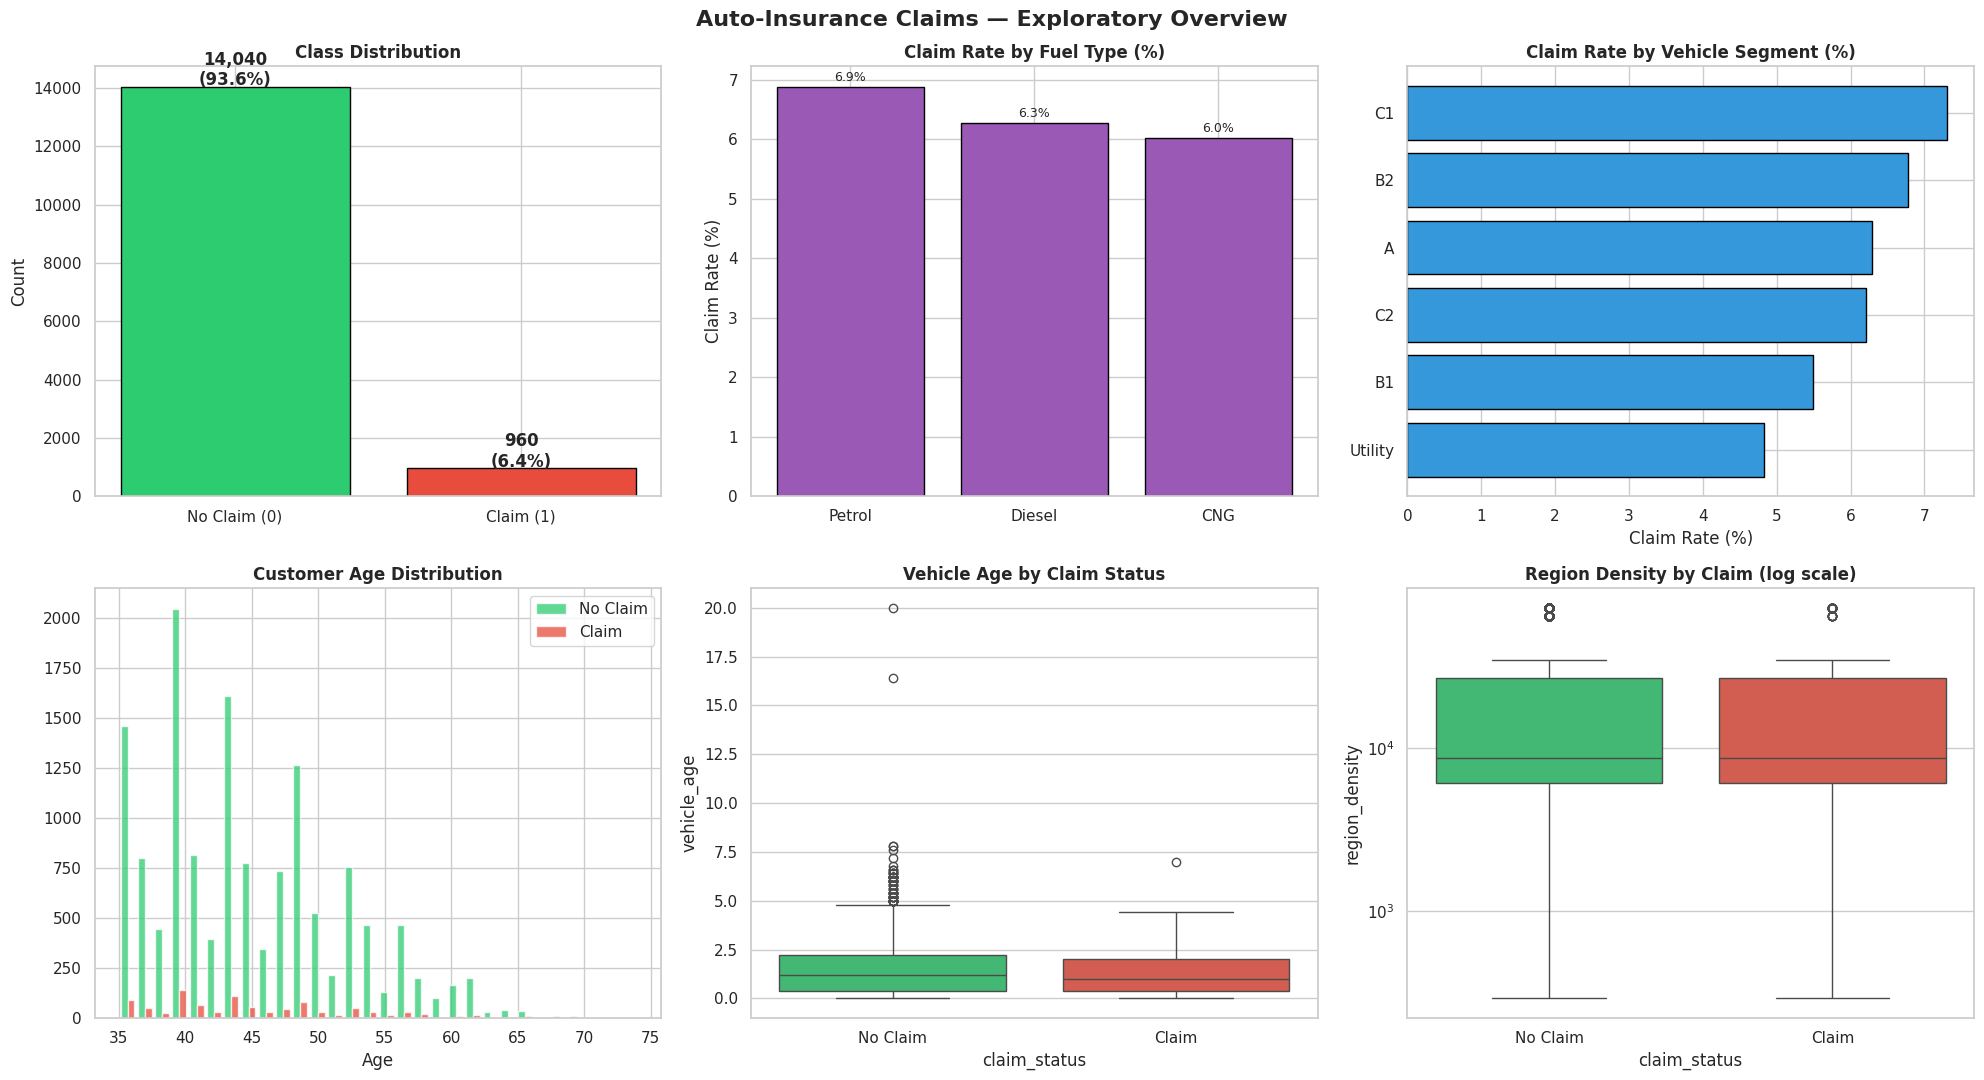

EDA saved.


In [5]:
df = df_raw.copy()
df.dropna(subset=['claim_status'], inplace=True)

# Stratified subsample for tractable training (preserves claim ratio)
MAX_TRAIN_SIZE = 15000
if len(df) > MAX_TRAIN_SIZE:
    df, _ = train_test_split(df, train_size=MAX_TRAIN_SIZE, random_state=42,
                             stratify=df['claim_status'])
df = df.reset_index(drop=True)
print(f"Working sample: {df.shape[0]:,} rows (stratified, claim ratio preserved)")

fig, axes = plt.subplots(2, 3, figsize=(20, 11))
fig.suptitle('Auto-Insurance Claims — Exploratory Overview',
             fontsize=16, fontweight='bold')

# 1. Target class balance
ax = axes[0,0]
counts = df['claim_status'].value_counts()
bars = ax.bar(['No Claim (0)', 'Claim (1)'], counts.values,
              color=['#2ecc71', '#e74c3c'], edgecolor='black')
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
            f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontweight='bold')
ax.set_title('Class Distribution', fontweight='bold')
ax.set_ylabel('Count')

# 2. Claim rate by fuel type
ax = axes[0,1]
fuel_rate = df.groupby('fuel_type')['claim_status'].mean().sort_values(ascending=False) * 100
ax.bar(fuel_rate.index, fuel_rate.values, color='#9b59b6', edgecolor='black')
ax.set_title('Claim Rate by Fuel Type (%)', fontweight='bold')
ax.set_ylabel('Claim Rate (%)')
for i,v in enumerate(fuel_rate.values): ax.text(i, v+0.1, f'{v:.1f}%', ha='center', fontsize=9)

# 3. Claim rate by segment
ax = axes[0,2]
seg_rate = df.groupby('segment')['claim_status'].mean().sort_values(ascending=True) * 100
ax.barh(seg_rate.index, seg_rate.values, color='#3498db', edgecolor='black')
ax.set_title('Claim Rate by Vehicle Segment (%)', fontweight='bold')
ax.set_xlabel('Claim Rate (%)')

# 4. Customer age distribution
ax = axes[1,0]
ax.hist([df[df['claim_status']==0]['customer_age'], df[df['claim_status']==1]['customer_age']],
        bins=30, color=['#2ecc71', '#e74c3c'], edgecolor='white',
        label=['No Claim', 'Claim'], alpha=0.75)
ax.set_title('Customer Age Distribution', fontweight='bold')
ax.set_xlabel('Age')
ax.legend()

# 5. Vehicle age by claim status
ax = axes[1,1]
sns.boxplot(data=df, x='claim_status', y='vehicle_age',
            palette=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_xticklabels(['No Claim', 'Claim'])
ax.set_title('Vehicle Age by Claim Status', fontweight='bold')

# 6. Region density (log scale) by claim status
ax = axes[1,2]
sns.boxplot(data=df, x='claim_status', y='region_density',
            palette=['#2ecc71', '#e74c3c'], ax=ax)
ax.set_yscale('log')
ax.set_xticklabels(['No Claim', 'Claim'])
ax.set_title('Region Density by Claim (log scale)', fontweight='bold')

plt.tight_layout()
plt.savefig('01_data_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print("EDA saved.")

## Feature Engineering & Preprocessing

In [6]:
# ── Parse engine specs (Nm, bhp), encode binaries & categoricals ─────────────
data = df.copy()

def parse_torque(s):
    m = re.search(r'([\d.]+)\s*[Nn][Mm]', str(s))
    return float(m.group(1)) if m else np.nan

def parse_power(s):
    m = re.search(r'([\d.]+)\s*bhp', str(s))
    return float(m.group(1)) if m else np.nan

data['torque_nm'] = data['max_torque'].apply(parse_torque)
data['power_bhp'] = data['max_power'].apply(parse_power)

binary_cols = [c for c in data.columns if c.startswith('is_')]
for col in binary_cols:
    data[col] = (data[col] == 'Yes').astype(int)

cat_encode = ['fuel_type', 'segment', 'model', 'transmission_type',
              'steering_type', 'rear_brakes_type', 'region_code']
for col in cat_encode:
    if col in data.columns:
        data[col] = LabelEncoder().fit_transform(data[col].astype(str))

# Catch any remaining string columns (handles schema drift gracefully)
for col in data.select_dtypes(include=['object']).columns:
    if col == 'policy_id':  # dropped below
        continue
    data[col] = LabelEncoder().fit_transform(data[col].astype(str))

# ── Engineered composite features ────────────────────────────────────────────
safety_cols = [c for c in data.columns if c.startswith('is_')]
data['safety_feature_count'] = data[safety_cols].sum(axis=1)

data['age_x_vehicle_age']    = data['customer_age'] * data['vehicle_age']
data['power_to_weight']      = (data['power_bhp'] / data['gross_weight']).round(4)
data['risk_density_x_age']   = (data['region_density'] * data['vehicle_age'] / 1000).round(4)

drop_cols = ['policy_id', 'max_torque', 'max_power', 'engine_type']
data = data.drop(columns=drop_cols)
# Sanitize: replace inf/-inf with NaN before median imputation
data = data.replace([np.inf, -np.inf], np.nan)
data = data.fillna(data.median(numeric_only=True))

print(f"Feature matrix : {data.shape[0]:,} rows × {data.shape[1]-1} features + 1 target")
print(f"Target column  : 'claim_status'")

Feature matrix : 15,000 rows × 42 features + 1 target
Target column  : 'claim_status'


In [7]:
# ── Train/test split + scaling + SMOTE for oversampling experiments ─────────
# For premium pricing, do not allow any claim amount / premium outcome columns to leak into X.
y = data['claim_status'].astype(int)

severity_candidates = [
    'claim_amount', 'claim_cost', 'claim_value', 'claim_size', 'loss_amount',
    'total_claim_amount', 'incurred_loss', 'paid_loss', 'claim_severity'
]
premium_leakage_candidates = [
    'premium', 'premium_amount', 'annual_premium', 'base_premium', 'policy_premium',
    'risk_premium', 'final_premium'
]
severity_col = next((c for c in severity_candidates if c in data.columns), None)
leakage_cols = [c for c in severity_candidates + premium_leakage_candidates if c in data.columns]

X = data.drop(columns=['claim_status'] + leakage_cols, errors='ignore')
feature_names = list(X.columns)
severity = data[severity_col].fillna(0) if severity_col else None

if severity_col:
    X_train_full, X_test, y_train_full, y_test, sev_train_full, sev_test = train_test_split(
        X, y, severity, test_size=0.20, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val, sev_train, sev_val = train_test_split(
        X_train_full, y_train_full, sev_train_full, test_size=0.15, random_state=42, stratify=y_train_full)
    print(f"Severity target detected and kept out of predictors: {severity_col}")
else:
    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X, y, test_size=0.20, random_state=42, stratify=y)
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full, y_train_full, test_size=0.15, random_state=42, stratify=y_train_full)
    sev_train = sev_val = sev_test = None
    print("No claim severity column detected. Pricing will use claim-frequency risk relativities.")

print(f"Train : {len(X_train):,}   claims={y_train.mean()*100:.1f}%")
print(f"Val   : {len(X_val):,}   claims={y_val.mean()*100:.1f}%")
print(f"Test  : {len(X_test):,}   claims={y_test.mean()*100:.1f}%")

# Scaled versions (for Logistic Regression, neural networks)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)

# SMOTE on training set only (kept for comparison, not used for final pricing model)
smote = SMOTE(sampling_strategy=0.50, random_state=42, k_neighbors=5)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)
print(f"\nAfter SMOTE — Train: {len(X_train_sm):,}  claims={y_train_sm.mean()*100:.1f}%")

scale_pos = float((y_train==0).sum() / max((y_train==1).sum(), 1))
sqrt_scale_pos = float(np.sqrt(scale_pos))
print(f"Class imbalance ratio (train) : 1 : {scale_pos:.1f}")
print(f"Pricing model will compare scale_pos_weight values: 1.0, sqrt ratio={sqrt_scale_pos:.2f}, full ratio={scale_pos:.2f}")


No claim severity column detected. Pricing will use claim-frequency risk relativities.
Train : 10,200   claims=6.4%
Val   : 1,800   claims=6.4%
Test  : 3,000   claims=6.4%

After SMOTE — Train: 14,320  claims=33.3%
Class imbalance ratio (train) : 1 : 14.6
Pricing model will compare scale_pos_weight values: 1.0, sqrt ratio=3.82, full ratio=14.62


## Evaluation Framework

In [8]:
results = {}

def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    t0 = time.time()
    model.fit(X_tr, y_tr)
    elapsed = time.time() - t0

    y_pred = model.predict(X_te)
    try:    y_prob = model.predict_proba(X_te)[:,1]
    except: y_prob = y_pred.astype(float)

    metrics = {
        'AUC-ROC':        round(roc_auc_score(y_te, y_prob), 4),
        'F1-Score':       round(f1_score(y_te, y_pred), 4),
        'Precision':      round(precision_score(y_te, y_pred), 4),
        'Recall':         round(recall_score(y_te, y_pred), 4),
        'MCC':            round(matthews_corrcoef(y_te, y_pred), 4),
        'Avg Precision':  round(average_precision_score(y_te, y_prob), 4),
        'Log Loss':       round(log_loss(y_te, y_prob), 4),
        'Train Time (s)': round(elapsed, 2),
        'model': model, 'y_prob': y_prob, 'y_pred': y_pred,
    }
    results[name] = metrics
    print(f"  [{name:55s}]  AUC={metrics['AUC-ROC']:.4f}  "
          f"F1={metrics['F1-Score']:.4f}  MCC={metrics['MCC']:.4f}  "
          f"LogLoss={metrics['Log Loss']:.4f}")
    return model

print("Evaluation helper ready.")

Evaluation helper ready.


## Baseline Models

In [9]:
print("=" * 75)
print("  BASELINE MODELS")
print("=" * 75)

# 1. Logistic Regression — also reused as the GLM warm-start for the CANN below
lr_baseline = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
evaluate_model('1. Logistic Regression', lr_baseline,
               X_train_sc, y_train, X_test_sc, y_test)

# 2. Random Forest
evaluate_model('2. Random Forest (Baseline)',
    RandomForestClassifier(n_estimators=200, max_depth=12, min_samples_leaf=10,
                           class_weight='balanced', n_jobs=-1, random_state=42),
    X_train, y_train, X_test, y_test)

# 3. XGBoost
evaluate_model('3. XGBoost (Baseline)',
    XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                  subsample=0.8, colsample_bytree=0.8, scale_pos_weight=scale_pos,
                  eval_metric='logloss', n_jobs=-1, random_state=42, verbosity=0),
    X_train, y_train, X_test, y_test)

# 4. LightGBM
evaluate_model('4. LightGBM (Baseline)',
    lgb.LGBMClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                       scale_pos_weight=scale_pos, n_jobs=-1, random_state=42, verbose=-1),
    X_train, y_train, X_test, y_test)

  BASELINE MODELS
  [1. Logistic Regression                                 ]  AUC=0.6003  F1=0.1428  MCC=0.0652  LogLoss=0.6797
  [2. Random Forest (Baseline)                            ]  AUC=0.6119  F1=0.1795  MCC=0.1100  LogLoss=0.4805
  [3. XGBoost (Baseline)                                  ]  AUC=0.5990  F1=0.1534  MCC=0.0766  LogLoss=0.5222
  [4. LightGBM (Baseline)                                 ]  AUC=0.6171  F1=0.1648  MCC=0.0944  LogLoss=0.5180


LGBMClassifier(max_depth=4, n_estimators=200, n_jobs=-1, random_state=42,
               scale_pos_weight=14.620214395099541, verbose=-1)

## Models with SMOTE Oversampling

In [10]:
print("=" * 75)
print("  SMOTE MODELS")
print("=" * 75)

# 5. Random Forest + SMOTE
evaluate_model('5. Random Forest + SMOTE',
    RandomForestClassifier(n_estimators=300, max_depth=14, min_samples_leaf=8,
                           n_jobs=-1, random_state=42),
    X_train_sm, y_train_sm, X_test, y_test)

# 6. XGBoost + SMOTE
evaluate_model('6. XGBoost + SMOTE',
    XGBClassifier(n_estimators=300, max_depth=5, learning_rate=0.08,
                  subsample=0.8, colsample_bytree=0.8, reg_alpha=0.1, reg_lambda=1.0,
                  eval_metric='logloss', n_jobs=-1, random_state=42, verbosity=0),
    X_train_sm, y_train_sm, X_test, y_test)

  SMOTE MODELS
  [5. Random Forest + SMOTE                               ]  AUC=0.6087  F1=0.1222  MCC=0.0794  LogLoss=0.3705
  [6. XGBoost + SMOTE                                     ]  AUC=0.5971  F1=0.1149  MCC=0.0770  LogLoss=0.2902


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.08, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=-1,
              num_parallel_tree=None, ...)

## Hyperparameter Tuning via RandomizedSearchCV

In [11]:
print("=" * 75)
print("  HYPERPARAMETER TUNING (XGBoost — RandomizedSearchCV + SMOTE)")
print("=" * 75)

cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

xgb_param_dist = {
    'n_estimators':     [200, 300, 500],
    'max_depth':        [4, 5, 6],
    'learning_rate':    [0.03, 0.05, 0.1],
    'subsample':        [0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [5, 10],
    'reg_alpha':        [0.0, 0.1],
}

xgb_rs = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', n_jobs=1,
                  random_state=42, verbosity=0, tree_method='hist'),
    xgb_param_dist, n_iter=8, cv=cv3, scoring='roc_auc',
    n_jobs=-1, random_state=42, verbose=1)

print("Tuning XGBoost on SMOTE-resampled training set...", flush=True)
xgb_rs.fit(X_train_sm, y_train_sm)
xgb_best_params = xgb_rs.best_params_
print(f"\nBest XGB Params : {xgb_best_params}")
print(f"CV AUC-ROC      : {xgb_rs.best_score_:.4f}")

# 7. XGBoost Tuned + SMOTE
evaluate_model('7. XGBoost Tuned (RandomizedSearchCV + SMOTE)',
    xgb_rs.best_estimator_, X_train_sm, y_train_sm, X_test, y_test)

  HYPERPARAMETER TUNING (XGBoost — RandomizedSearchCV + SMOTE)
Tuning XGBoost on SMOTE-resampled training set...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best XGB Params : {'subsample': 0.9, 'reg_alpha': 0.1, 'n_estimators': 500, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.1, 'colsample_bytree': 0.9}
CV AUC-ROC      : 0.9398
  [7. XGBoost Tuned (RandomizedSearchCV + SMOTE)          ]  AUC=0.5769  F1=0.1203  MCC=0.0757  LogLoss=0.3029


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.9, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=5, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=500, n_jobs=1,
              num_parallel_tree=None, ...)

## Neural Network Components — MLP & CANN

The hybrid framework requires two neural feature extractors:
- **InsuranceMLP**: a vanilla MLP (100→50) used as a baseline hybrid (Phase-1 of original DL-GB approach).
- **CANN**: a Combined Actuarial Neural Network with a GLM skip connection, where the final logit is `GLM(x) + NN_residual(x)`. The GLM weights are warm-started from the trained Logistic Regression to anchor the model on the linear actuarial baseline.

In [12]:
# ── Vanilla MLP for the original-style hybrid ───────────────────────────────
class InsuranceMLP(nn.Module):
    def __init__(self, input_dim, hidden1=100, hidden2=50):
        super().__init__()
        self.feature_extractor = nn.Sequential(
            nn.Linear(input_dim, hidden1), nn.ReLU(),
            nn.BatchNorm1d(hidden1), nn.Dropout(0.3),
            nn.Linear(hidden1, hidden2), nn.ReLU(),
            nn.BatchNorm1d(hidden2), nn.Dropout(0.2),
        )
        self.classifier = nn.Linear(hidden2, 1)

    def forward(self, x):
        return torch.sigmoid(self.classifier(self.feature_extractor(x)))

    def extract_features(self, x):
        with torch.no_grad():
            return self.feature_extractor(x)


# ── CANN: Combined Actuarial Neural Network (Wuthrich & Merz, 2019) ─────────
class CANN(nn.Module):
    """output = sigmoid( GLM_logit(x) + NN_residual(x) )"""
    def __init__(self, input_dim):
        super().__init__()
        self.glm = nn.Linear(input_dim, 1)            # linear actuarial skip
        self.nn_branch = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.BatchNorm1d(128), nn.Dropout(0.3),
            nn.Linear(128, 64),  nn.ReLU(),
            nn.BatchNorm1d(64),  nn.Dropout(0.2),
            nn.Linear(64,  32),  nn.ReLU(),
            nn.BatchNorm1d(32),  nn.Dropout(0.1),
        )
        self.nn_head = nn.Linear(32, 1)

    def forward(self, x):
        return torch.sigmoid(self.glm(x) + self.nn_head(self.nn_branch(x)))

    def extract_features(self, x):
        with torch.no_grad():
            return self.nn_branch(x)


def train_nn(model, X_tr, y_tr, X_val, y_val, epochs=120, lr=5e-4,
             patience=20, weighted=True):
    pos_w = torch.tensor([float((y_tr==0).sum() / max((y_tr==1).sum(), 1))]).to(device)
    criterion = nn.BCELoss(reduction='none')
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=7, factor=0.5)

    X_t = torch.FloatTensor(X_tr).to(device); y_t = torch.FloatTensor(y_tr).to(device).unsqueeze(1)
    X_v = torch.FloatTensor(X_val).to(device); y_v = torch.FloatTensor(y_val).to(device).unsqueeze(1)
    w_t = torch.where(y_t==1, pos_w, torch.ones(1).to(device)) if weighted else torch.ones_like(y_t)
    w_v = torch.where(y_v==1, pos_w, torch.ones(1).to(device)) if weighted else torch.ones_like(y_v)

    best_loss, patience_cnt, best_state = float('inf'), 0, None
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = (criterion(model(X_t), y_t) * w_t).mean()
        loss.backward(); optimizer.step()

        model.eval()
        with torch.no_grad():
            v_loss = (criterion(model(X_v), y_v) * w_v).mean().item()
        scheduler.step(v_loss)

        if v_loss < best_loss:
            best_loss, patience_cnt = v_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_cnt += 1
            if patience_cnt >= patience: break

    model.load_state_dict(best_state)
    print(f"  Trained {epoch+1} epochs, best val loss: {best_loss:.4f}")
    return model

print("Neural network components ready.")

Neural network components ready.


## Hybrid Architectures: MLP-XGB, CANN, CANN-XGB [PROPOSED], CANN-LGBM

In [13]:
print("=" * 75)
print("  HYBRID NEURAL + GRADIENT-BOOSTING MODELS")
print("=" * 75)

# ── 8. Original MLP + XGBoost hybrid ─────────────────────────────────────────
print("\n[Phase 1] Training InsuranceMLP (100-50)...")
mlp = InsuranceMLP(X_train_sc.shape[1], 100, 50).to(device)
mlp = train_nn(mlp, X_train_sc, y_train.values,
               scaler.transform(X_val), y_val.values, epochs=100, lr=1e-3, patience=15)

mlp.eval()
mlp_train_deep = mlp.extract_features(torch.FloatTensor(X_train_sc).to(device)).cpu().numpy()
mlp_test_deep  = mlp.extract_features(torch.FloatTensor(X_test_sc).to(device)).cpu().numpy()
X_train_mlp_hyb = np.hstack((X_train.values, mlp_train_deep))
X_test_mlp_hyb  = np.hstack((X_test.values,  mlp_test_deep))

print("[Phase 2] XGBoost on MLP-augmented features...")
evaluate_model('8. Hybrid MLP + XGBoost',
    XGBClassifier(n_estimators=200, max_depth=4, learning_rate=0.1,
                  scale_pos_weight=scale_pos, eval_metric='logloss',
                  n_jobs=-1, random_state=42, verbosity=0),
    X_train_mlp_hyb, y_train, X_test_mlp_hyb, y_test)

  HYBRID NEURAL + GRADIENT-BOOSTING MODELS

[Phase 1] Training InsuranceMLP (100-50)...
  Trained 67 epochs, best val loss: 1.2518
[Phase 2] XGBoost on MLP-augmented features...
  [8. Hybrid MLP + XGBoost                                ]  AUC=0.5898  F1=0.1527  MCC=0.0751  LogLoss=0.4767


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=200, n_jobs=-1,
              num_parallel_tree=None, ...)

In [14]:
# ── 9. CANN Standalone ──────────────────────────────────────────────────────
print("\n[Phase 1] Training CANN (128-64-32 + GLM skip connection)...")
cann = CANN(X_train_sc.shape[1]).to(device)

# Warm-start GLM weights from the trained Logistic Regression
with torch.no_grad():
    cann.glm.weight.copy_(torch.FloatTensor(lr_baseline.coef_[0]).unsqueeze(0))
    cann.glm.bias.copy_(torch.FloatTensor(lr_baseline.intercept_))
print("  GLM skip connection initialised from Logistic Regression coefficients.")

cann = train_nn(cann, X_train_sc, y_train.values,
                scaler.transform(X_val), y_val.values, epochs=150, lr=5e-4, patience=20)

# Evaluate CANN as a standalone classifier
cann.eval()
with torch.no_grad():
    cann_probs = cann(torch.FloatTensor(X_test_sc).to(device)).cpu().numpy().ravel()

class _CANNWrapper:
    """sklearn-style wrapper so evaluate_model can reuse the CANN."""
    def __init__(self, model, sc): self.model, self.sc = model, sc
    def fit(self, X, y): return self
    def predict_proba(self, X):
        Xs = self.sc.transform(X) if isinstance(X, pd.DataFrame) else X
        with torch.no_grad():
            p = self.model(torch.FloatTensor(Xs).to(device)).cpu().numpy().ravel()
        return np.column_stack([1-p, p])
    def predict(self, X): return (self.predict_proba(X)[:,1] > 0.5).astype(int)

evaluate_model('9. CANN Standalone',
    _CANNWrapper(cann, scaler), X_train, y_train, X_test, y_test)


[Phase 1] Training CANN (128-64-32 + GLM skip connection)...
  GLM skip connection initialised from Logistic Regression coefficients.
  Trained 23 epochs, best val loss: 1.2789
  [9. CANN Standalone                                     ]  AUC=0.5979  F1=0.1462  MCC=0.0680  LogLoss=0.6426


In [15]:
# ── 10. PROPOSED — Hybrid CANN + XGBoost (Tuned ON the hybrid space) ────────
print("\n[Phase 2] Building hybrid feature space (raw features + 32-dim CANN embeddings)...")
cann_train_deep = cann.extract_features(torch.FloatTensor(X_train_sc).to(device)).cpu().numpy()
cann_val_deep   = cann.extract_features(torch.FloatTensor(X_val_sc).to(device)).cpu().numpy()
cann_test_deep  = cann.extract_features(torch.FloatTensor(X_test_sc).to(device)).cpu().numpy()
X_train_cann_hyb = np.hstack((X_train.values, cann_train_deep))
X_val_cann_hyb   = np.hstack((X_val.values,   cann_val_deep))
X_test_cann_hyb  = np.hstack((X_test.values,  cann_test_deep))
print(f"  Hybrid feature dim: {X_train_cann_hyb.shape[1]} "
      f"({X_train.shape[1]} raw + {cann_train_deep.shape[1]} CANN-deep)")

# ── Tune XGBoost ON the hybrid feature space (NOT on raw+SMOTE) ─────────────
print("\n[Phase 2a] Tuning XGBoost on the hybrid space...")
xgb_hybrid_param_dist = {
    'n_estimators':     [200, 400, 600],
    'max_depth':        [3, 4, 5, 6],
    'learning_rate':    [0.02, 0.05, 0.1],
    'subsample':        [0.7, 0.8, 0.9],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 5, 10],
    'reg_alpha':        [0.0, 0.1, 1.0],
    'reg_lambda':       [1.0, 5.0],
}
xgb_hyb_rs = RandomizedSearchCV(
    XGBClassifier(eval_metric='logloss', n_jobs=1, random_state=42,
                  verbosity=0, tree_method='hist',
                  scale_pos_weight=scale_pos),
    xgb_hybrid_param_dist, n_iter=12, cv=cv3, scoring='roc_auc',
    n_jobs=-1, random_state=42, verbose=1)
xgb_hyb_rs.fit(X_train_cann_hyb, y_train)
xgb_hyb_best = xgb_hyb_rs.best_params_
print(f"\n  Best params (hybrid space): {xgb_hyb_best}")
print(f"  CV AUC-ROC                : {xgb_hyb_rs.best_score_:.4f}")

# ── Fit the final model and tune the decision threshold on validation ──────
proposed_xgb = XGBClassifier(
    **xgb_hyb_best, scale_pos_weight=scale_pos,
    eval_metric='logloss', n_jobs=-1, random_state=42,
    verbosity=0, tree_method='hist')
proposed_xgb.fit(X_train_cann_hyb, y_train)

val_probs = proposed_xgb.predict_proba(X_val_cann_hyb)[:, 1]
thresholds = np.linspace(0.05, 0.60, 56)
f1s = [f1_score(y_val, (val_probs >= t).astype(int)) for t in thresholds]
best_thresh = float(thresholds[int(np.argmax(f1s))])
print(f"  Best threshold (val F1): {best_thresh:.3f}  →  val F1={max(f1s):.4f}")

class _ThresholdedClassifier:
    """Wraps a fitted classifier with a custom decision threshold."""
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold
        self.feature_importances_ = model.feature_importances_
    def fit(self, X, y): return self  # already fitted
    def predict_proba(self, X): return self.model.predict_proba(X)
    def predict(self, X):
        return (self.model.predict_proba(X)[:, 1] >= self.threshold).astype(int)
    def save_model(self, path): self.model.save_model(path)

proposed_model = _ThresholdedClassifier(proposed_xgb, threshold=best_thresh)
evaluate_model('10. ★ Hybrid CANN + XGBoost (Tuned) [PROPOSED]',
    proposed_model, X_train_cann_hyb, y_train, X_test_cann_hyb, y_test)

# ── 11. Hybrid CANN + LightGBM (comparison) ─────────────────────────────────
evaluate_model('11. Hybrid CANN + LightGBM (Tuned)',
    lgb.LGBMClassifier(
        n_estimators=xgb_hyb_best.get('n_estimators', 400),
        learning_rate=xgb_hyb_best.get('learning_rate', 0.05),
        max_depth=xgb_hyb_best.get('max_depth', 5),
        scale_pos_weight=scale_pos,
        n_jobs=-1, random_state=42, verbose=-1),
    X_train_cann_hyb, y_train, X_test_cann_hyb, y_test)

print("\nAll 11 models trained.")


[Phase 2] Building hybrid feature space (raw features + 32-dim CANN embeddings)...
  Hybrid feature dim: 74 (42 raw + 32 CANN-deep)

[Phase 2a] Tuning XGBoost on the hybrid space...
Fitting 3 folds for each of 12 candidates, totalling 36 fits

  Best params (hybrid space): {'subsample': 0.8, 'reg_lambda': 5.0, 'reg_alpha': 1.0, 'n_estimators': 400, 'min_child_weight': 10, 'max_depth': 5, 'learning_rate': 0.02, 'colsample_bytree': 0.6}
  CV AUC-ROC                : 0.5863
  Best threshold (val F1): 0.300  →  val F1=0.1517
  [10. ★ Hybrid CANN + XGBoost (Tuned) [PROPOSED]         ]  AUC=0.6045  F1=0.1436  MCC=0.0808  LogLoss=0.5181
  [11. Hybrid CANN + LightGBM (Tuned)                     ]  AUC=0.5809  F1=0.1300  MCC=0.0421  LogLoss=0.5163

All 11 models trained.


## Pricing-Focused Improvement: Calibrated Expected-Loss Model

The earlier proposed model was evaluated mainly as a classifier. For premium pricing, the more important output is a **well-calibrated probability of claim**, because the technical premium is based on expected loss:

\[
\text{Expected Loss} = P(\text{claim}) \times E(\text{claim severity} \mid \text{claim})
\]

This section improves the model by:
1. Tuning XGBoost on the CANN hybrid feature space using **log-loss**, which rewards better probability estimates.
2. Comparing class-weight strengths instead of automatically using the full imbalance ratio.
3. Calibrating predicted probabilities using validation data.
4. Selecting classification thresholds only for reporting, while pricing uses the calibrated probability directly.


In [16]:
print("=" * 85)
print("  PRICING-FOCUSED PROPOSED MODEL: Calibrated CANN + XGBoost")
print("=" * 85)

from sklearn.calibration import CalibratedClassifierCV
from sklearn.metrics import brier_score_loss
from xgboost import XGBRegressor


def expected_calibration_error(y_true, y_prob, n_bins=10):
    """Simple ECE for probability calibration diagnostics."""
    y_true = np.asarray(y_true)
    y_prob = np.asarray(y_prob)
    bins = np.linspace(0.0, 1.0, n_bins + 1)
    ece = 0.0
    for lo, hi in zip(bins[:-1], bins[1:]):
        mask = (y_prob >= lo) & (y_prob < hi if hi < 1 else y_prob <= hi)
        if mask.sum() == 0:
            continue
        ece += (mask.sum() / len(y_prob)) * abs(y_true[mask].mean() - y_prob[mask].mean())
    return float(ece)


def calibrate_prefit(model, X_cal, y_cal, method='isotonic'):
    """Version-tolerant CalibratedClassifierCV wrapper for already-fitted models."""
    try:
        cal = CalibratedClassifierCV(estimator=model, method=method, cv='prefit')
    except TypeError:
        cal = CalibratedClassifierCV(base_estimator=model, method=method, cv='prefit')
    cal.fit(X_cal, y_cal)
    return cal

# Tune for pricing: log-loss/probability quality, not only discrimination.
pricing_param_dist = {
    'n_estimators':     [300, 500, 700],
    'max_depth':        [2, 3, 4],
    'learning_rate':    [0.01, 0.03, 0.05],
    'subsample':        [0.75, 0.90, 1.00],
    'colsample_bytree': [0.70, 0.85, 1.00],
    'min_child_weight': [5, 10, 20],
    'reg_alpha':        [0.0, 0.1, 1.0],
    'reg_lambda':       [1.0, 5.0, 10.0],
}

weight_grid = [1.0, sqrt_scale_pos, scale_pos]
pricing_candidates = []

for spw in weight_grid:
    print(f"\nTuning candidate with scale_pos_weight={spw:.3f}")
    rs = RandomizedSearchCV(
        XGBClassifier(
            objective='binary:logistic', eval_metric='logloss', tree_method='hist',
            scale_pos_weight=spw, n_jobs=1, random_state=42, verbosity=0
        ),
        pricing_param_dist,
        n_iter=10,
        cv=cv3,
        scoring='neg_log_loss',
        n_jobs=-1,
        random_state=42,
        verbose=0
    )
    rs.fit(X_train_cann_hyb, y_train)
    raw = XGBClassifier(
        **rs.best_params_, objective='binary:logistic', eval_metric='logloss',
        tree_method='hist', scale_pos_weight=spw, n_jobs=-1,
        random_state=42, verbosity=0
    )
    raw.fit(X_train_cann_hyb, y_train)

    # Try both calibration methods; keep the one with lower validation log-loss.
    cal_options = []
    for method in ['sigmoid', 'isotonic']:
        try:
            cal = calibrate_prefit(raw, X_val_cann_hyb, y_val, method=method)
            val_p = cal.predict_proba(X_val_cann_hyb)[:, 1]
            cal_options.append((log_loss(y_val, val_p), brier_score_loss(y_val, val_p), method, cal, val_p))
        except Exception as e:
            print(f"  Calibration skipped for {method}: {type(e).__name__}: {e}")
    cal_options.sort(key=lambda z: z[0])
    best_ll, best_brier, best_method, best_cal, best_val_prob = cal_options[0]

    pricing_candidates.append({
        'scale_pos_weight': spw,
        'best_params': rs.best_params_,
        'raw_model': raw,
        'calibrated_model': best_cal,
        'calibration_method': best_method,
        'val_log_loss': best_ll,
        'val_brier': best_brier,
        'val_ece': expected_calibration_error(y_val, best_val_prob),
        'val_auc': roc_auc_score(y_val, best_val_prob),
        'val_ap': average_precision_score(y_val, best_val_prob),
    })
    print(f"  Best calibration={best_method:<8s} val log-loss={best_ll:.4f} brier={best_brier:.4f} AP={average_precision_score(y_val, best_val_prob):.4f}")

pricing_candidates_df = pd.DataFrame([
    {k: v for k, v in c.items() if k not in ['raw_model', 'calibrated_model', 'best_params']}
    for c in pricing_candidates
]).sort_values(['val_log_loss', 'val_brier'])
print("\nPricing candidate validation results:")
print(pricing_candidates_df.to_string(index=False))

best_pricing = sorted(pricing_candidates, key=lambda c: (c['val_log_loss'], c['val_brier']))[0]
pricing_raw_model = best_pricing['raw_model']
pricing_calibrated_model = best_pricing['calibrated_model']

# Thresholds are for reporting only; premium pricing uses the calibrated probabilities.
val_pricing_prob = pricing_calibrated_model.predict_proba(X_val_cann_hyb)[:, 1]
thresholds = np.linspace(0.01, 0.60, 120)
threshold_rows = []
for t in thresholds:
    pred = (val_pricing_prob >= t).astype(int)
    threshold_rows.append({
        'threshold': float(t),
        'f1': f1_score(y_val, pred, zero_division=0),
        'mcc': matthews_corrcoef(y_val, pred),
        'precision': precision_score(y_val, pred, zero_division=0),
        'recall': recall_score(y_val, pred, zero_division=0),
    })
threshold_df = pd.DataFrame(threshold_rows)
best_mcc_threshold = float(threshold_df.loc[threshold_df['mcc'].idxmax(), 'threshold'])
best_f1_threshold = float(threshold_df.loc[threshold_df['f1'].idxmax(), 'threshold'])

class _PricingCalibratedClassifier:
    """Calibrated classifier for pricing; predict_proba is the primary output."""
    def __init__(self, calibrated_model, raw_model, threshold=0.5):
        self.calibrated_model = calibrated_model
        self.raw_model = raw_model
        self.model = raw_model  # keeps SHAP/feature-importance compatibility
        self.threshold = threshold
        self.feature_importances_ = raw_model.feature_importances_
    def fit(self, X, y): return self
    def predict_proba(self, X): return self.calibrated_model.predict_proba(X)
    def predict(self, X): return (self.predict_proba(X)[:, 1] >= self.threshold).astype(int)
    def save_model(self, path): self.raw_model.save_model(path)

pricing_key = '12. ★ Pricing-Focused CANN + XGBoost (Calibrated) [PROPOSED]'
pricing_model = _PricingCalibratedClassifier(
    pricing_calibrated_model, pricing_raw_model, threshold=best_mcc_threshold
)

evaluate_model(pricing_key, pricing_model, X_train_cann_hyb, y_train, X_test_cann_hyb, y_test)

pricing_test_prob = results[pricing_key]['y_prob']
print("\nCalibration diagnostics on test set:")
print(f"  Brier score : {brier_score_loss(y_test, pricing_test_prob):.4f}  (lower is better)")
print(f"  ECE         : {expected_calibration_error(y_test, pricing_test_prob):.4f}  (lower is better)")
print(f"  Log loss    : {log_loss(y_test, pricing_test_prob):.4f}  (lower is better)")
print(f"  Best reporting threshold by validation MCC: {best_mcc_threshold:.3f}")
print(f"  Best reporting threshold by validation F1 : {best_f1_threshold:.3f}")
print("\nImportant: for pricing, use claim_probability = predict_proba(...), not the hard class prediction.")


  PRICING-FOCUSED PROPOSED MODEL: Calibrated CANN + XGBoost

Tuning candidate with scale_pos_weight=1.000
  Best calibration=isotonic val log-loss=0.2261 brier=0.0585 AP=0.0958

Tuning candidate with scale_pos_weight=3.824
  Best calibration=isotonic val log-loss=0.2289 brier=0.0589 AP=0.0885

Tuning candidate with scale_pos_weight=14.620
  Best calibration=isotonic val log-loss=0.2307 brier=0.0590 AP=0.0883

Pricing candidate validation results:
 scale_pos_weight calibration_method  val_log_loss  val_brier      val_ece  val_auc   val_ap
         1.000000           isotonic      0.226139   0.058548 1.834705e-09 0.652793 0.095770
         3.823639           isotonic      0.228909   0.058919 1.395949e-09 0.626701 0.088532
        14.620214           isotonic      0.230685   0.059037 2.643921e-10 0.614716 0.088333
  [12. ★ Pricing-Focused CANN + XGBoost (Calibrated) [PROPOSED]]  AUC=0.5866  F1=0.1438  MCC=0.0788  LogLoss=0.2579

Calibration diagnostics on test set:
  Brier score : 0.0598 

## Full Results Comparison

In [17]:
metrics_cols = ['AUC-ROC','F1-Score','Precision','Recall','MCC',
                'Avg Precision','Log Loss','Train Time (s)']
rows = [{'Model': k, **{m: v[m] for m in metrics_cols}} for k,v in results.items()]
results_df = pd.DataFrame(rows).set_index('Model')

print("\n" + "=" * 90)
print("           COMPLETE MODEL LEADERBOARD (ranked by PRICING-RELEVANT LOG LOSS)")
print("=" * 90)
lb = results_df.sort_values(['Log Loss','Avg Precision','MCC'], ascending=[True, False, False])
print(lb[['AUC-ROC','F1-Score','Precision','Recall','MCC','Avg Precision','Log Loss']].to_string())
print("=" * 90)

champion = lb.index[0]
print(f"\nPricing champion: {champion}")
print(f"   AUC-ROC       = {lb.loc[champion,'AUC-ROC']:.4f}")
print(f"   F1-Score      = {lb.loc[champion,'F1-Score']:.4f}")
print(f"   MCC           = {lb.loc[champion,'MCC']:.4f}")
print(f"   Avg Precision = {lb.loc[champion,'Avg Precision']:.4f}")
print(f"   Log Loss      = {lb.loc[champion,'Log Loss']:.4f}")



           COMPLETE MODEL LEADERBOARD (ranked by PRICING-RELEVANT LOG LOSS)
                                                              AUC-ROC  F1-Score  Precision  Recall     MCC  Avg Precision  Log Loss
Model                                                                                                                              
12. ★ Pricing-Focused CANN + XGBoost (Calibrated) [PROPOSED]   0.5866    0.1438     0.0795  0.7552  0.0788         0.0782    0.2579
6. XGBoost + SMOTE                                             0.5971    0.1149     0.1635  0.0885  0.0770         0.0976    0.2902
7. XGBoost Tuned (RandomizedSearchCV + SMOTE)                  0.5769    0.1203     0.1532  0.0990  0.0757         0.0901    0.3029
5. Random Forest + SMOTE                                       0.6087    0.1222     0.1597  0.0990  0.0794         0.0955    0.3705
8. Hybrid MLP + XGBoost                                        0.5898    0.1527     0.1005  0.3177  0.0751         0.0848    0.4767

## Visual Model Comparison

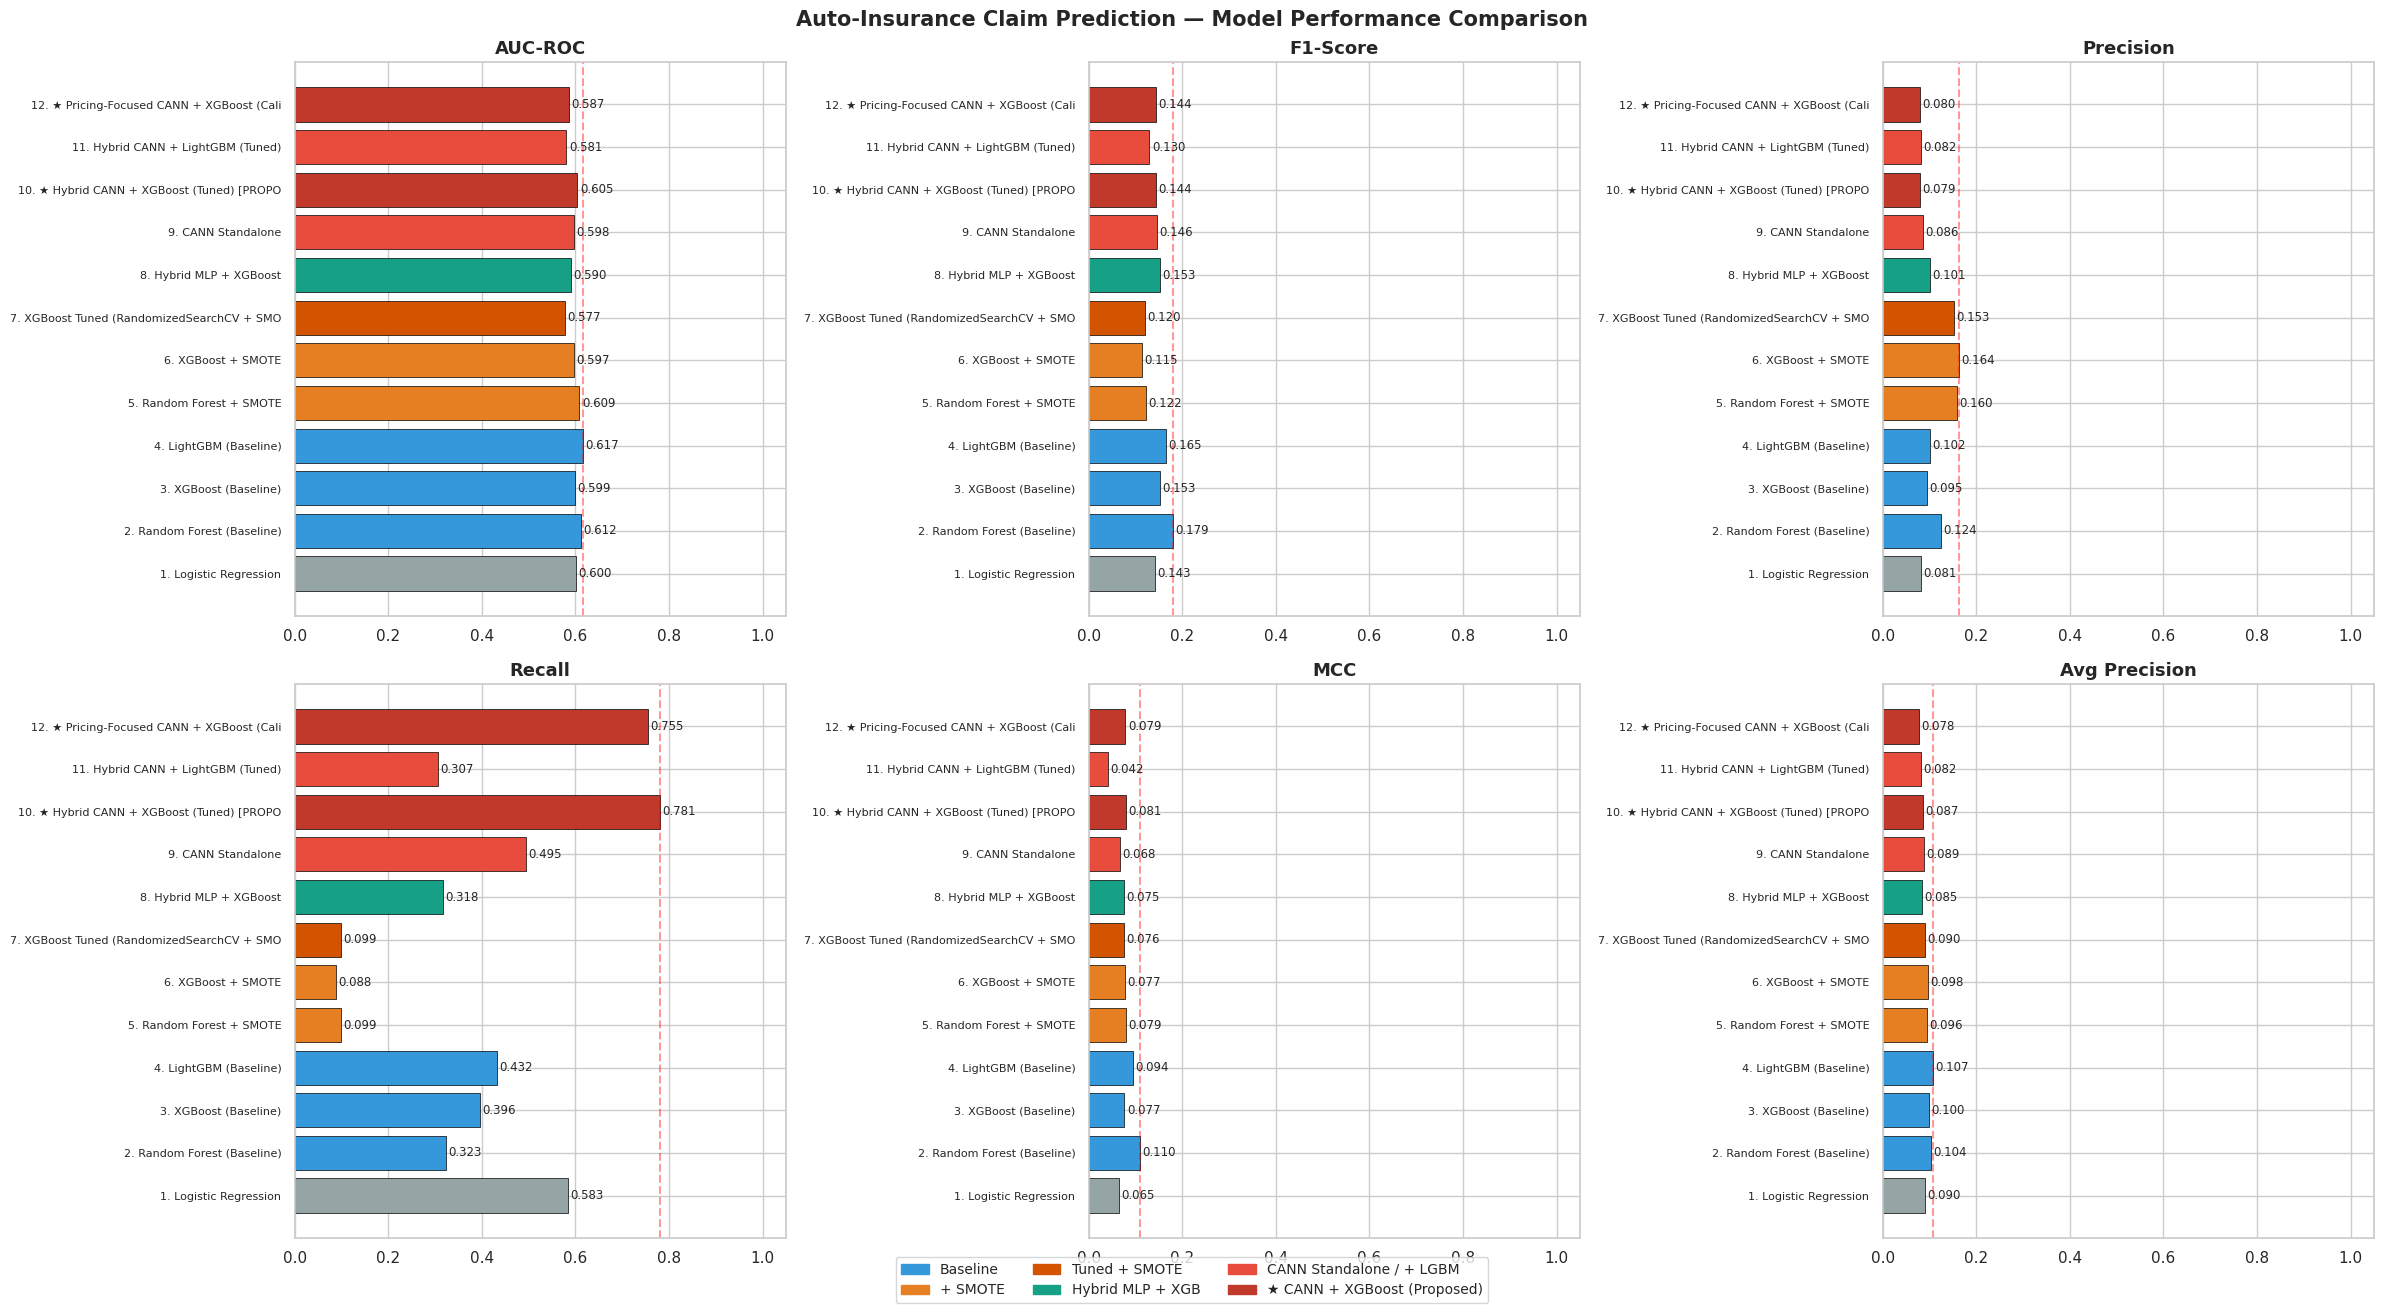

In [18]:
def bar_color(name):
    if '★' in name:        return '#c0392b'
    if 'CANN' in name:      return '#e74c3c'
    if 'MLP' in name:       return '#16a085'
    if 'Tuned' in name:     return '#d35400'
    if 'SMOTE' in name:     return '#e67e22'
    if 'Baseline' in name:  return '#3498db'
    return '#95a5a6'

short = [n[:42] for n in results_df.index]
plot_metrics = ['AUC-ROC','F1-Score','Precision','Recall','MCC','Avg Precision']
fig, axes = plt.subplots(2, 3, figsize=(24, 13))
fig.suptitle('Auto-Insurance Claim Prediction — Model Performance Comparison',
             fontsize=15, fontweight='bold')

for idx, metric in enumerate(plot_metrics):
    ax = axes[idx//3][idx%3]
    vals  = results_df[metric].values
    bclrs = [bar_color(n) for n in results_df.index]
    bars  = ax.barh(short, vals, color=bclrs, edgecolor='black', linewidth=0.5)
    ax.set_title(metric, fontweight='bold', fontsize=13)
    ax.set_xlim(0, max(1.05, vals.max()*1.1))
    ax.axvline(x=max(vals), color='red', linestyle='--', alpha=0.4, linewidth=1.5)
    for bar, val in zip(bars, vals):
        ax.text(val+0.005, bar.get_y()+bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8.5)
    ax.tick_params(axis='y', labelsize=8)

from matplotlib.patches import Patch
legend_els = [
    Patch(color='#3498db', label='Baseline'),
    Patch(color='#e67e22', label='+ SMOTE'),
    Patch(color='#d35400', label='Tuned + SMOTE'),
    Patch(color='#16a085', label='Hybrid MLP + XGB'),
    Patch(color='#e74c3c', label='CANN Standalone / + LGBM'),
    Patch(color='#c0392b', label='★ CANN + XGBoost (Proposed)'),
]
fig.legend(handles=legend_els, loc='lower center', ncol=3, fontsize=10,
           bbox_to_anchor=(0.5, -0.02))
plt.tight_layout()
plt.savefig('02_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## ROC & Precision–Recall Curves

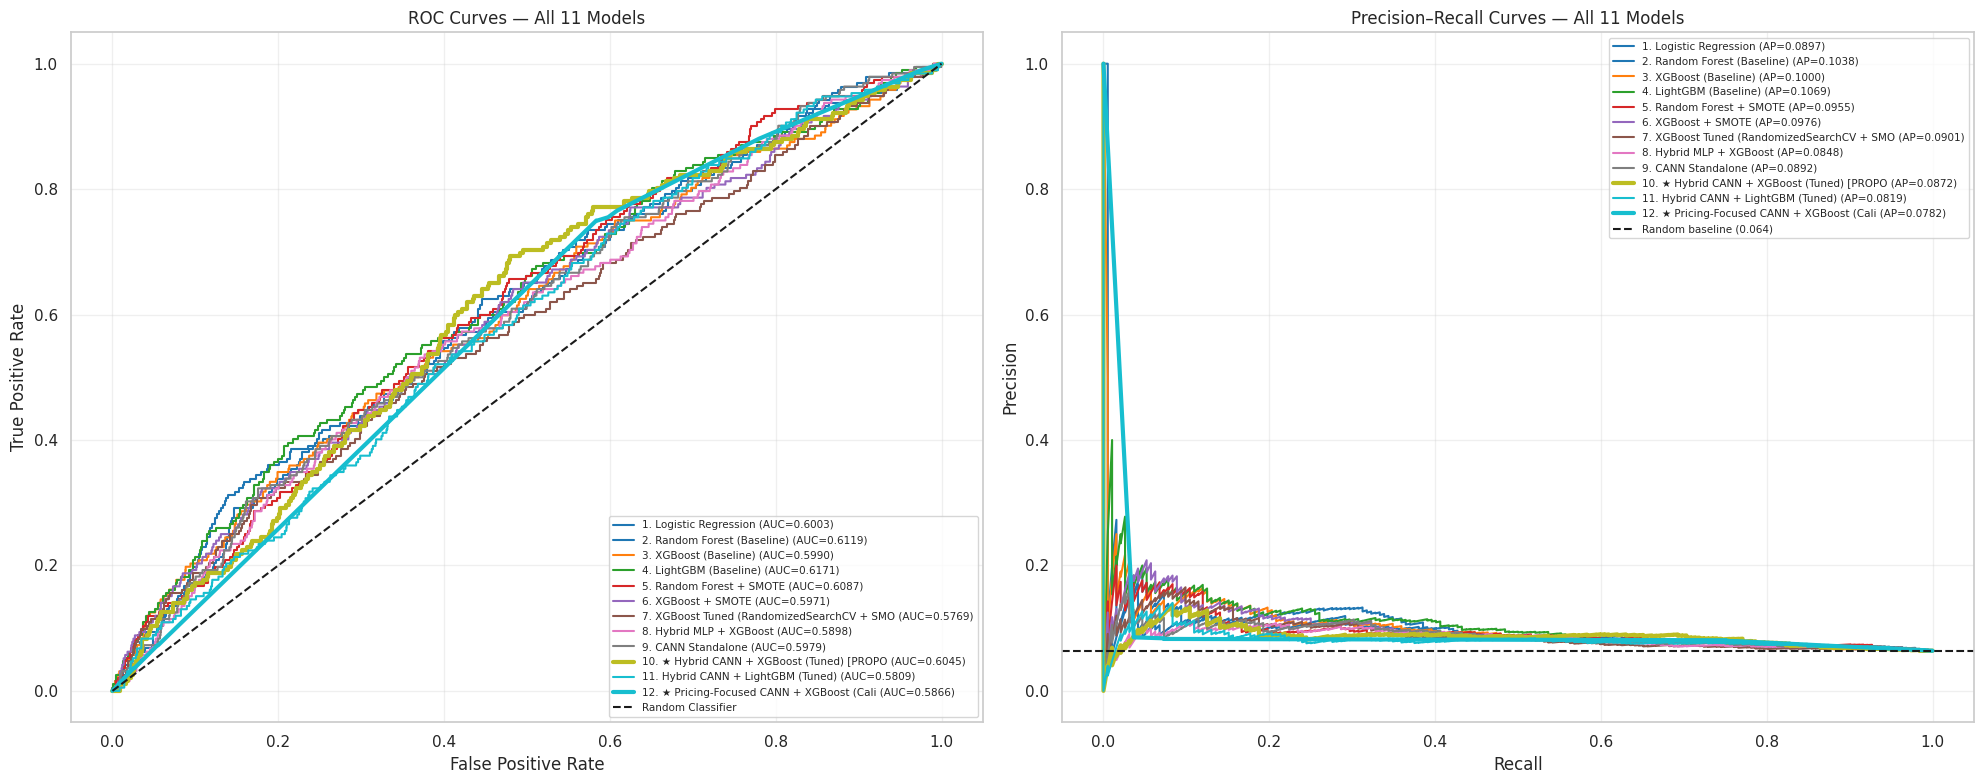

In [19]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))

cmap = plt.cm.tab10(np.linspace(0, 1, len(results)))
for i, (name, res) in enumerate(results.items()):
    lw  = 3 if '★' in name else 1.5
    col = cmap[i]
    short_n = name[:42]

    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax1.plot(fpr, tpr, lw=lw, color=col,
             label=f"{short_n} (AUC={res['AUC-ROC']:.4f})")

    pr, rc, _ = precision_recall_curve(y_test, res['y_prob'])
    ax2.plot(rc, pr, lw=lw, color=col,
             label=f"{short_n} (AP={res['Avg Precision']:.4f})")

ax1.plot([0,1],[0,1],'k--', label='Random Classifier')
ax1.set(xlabel='False Positive Rate', ylabel='True Positive Rate',
        title='ROC Curves — All 11 Models')
ax1.legend(loc='lower right', fontsize=7.5); ax1.grid(alpha=0.3)

ax2.axhline(y=y_test.mean(), color='k', linestyle='--',
            label=f'Random baseline ({y_test.mean():.3f})')
ax2.set(xlabel='Recall', ylabel='Precision',
        title='Precision–Recall Curves — All 11 Models')
ax2.legend(loc='upper right', fontsize=7.5); ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('03_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Confusion Matrices

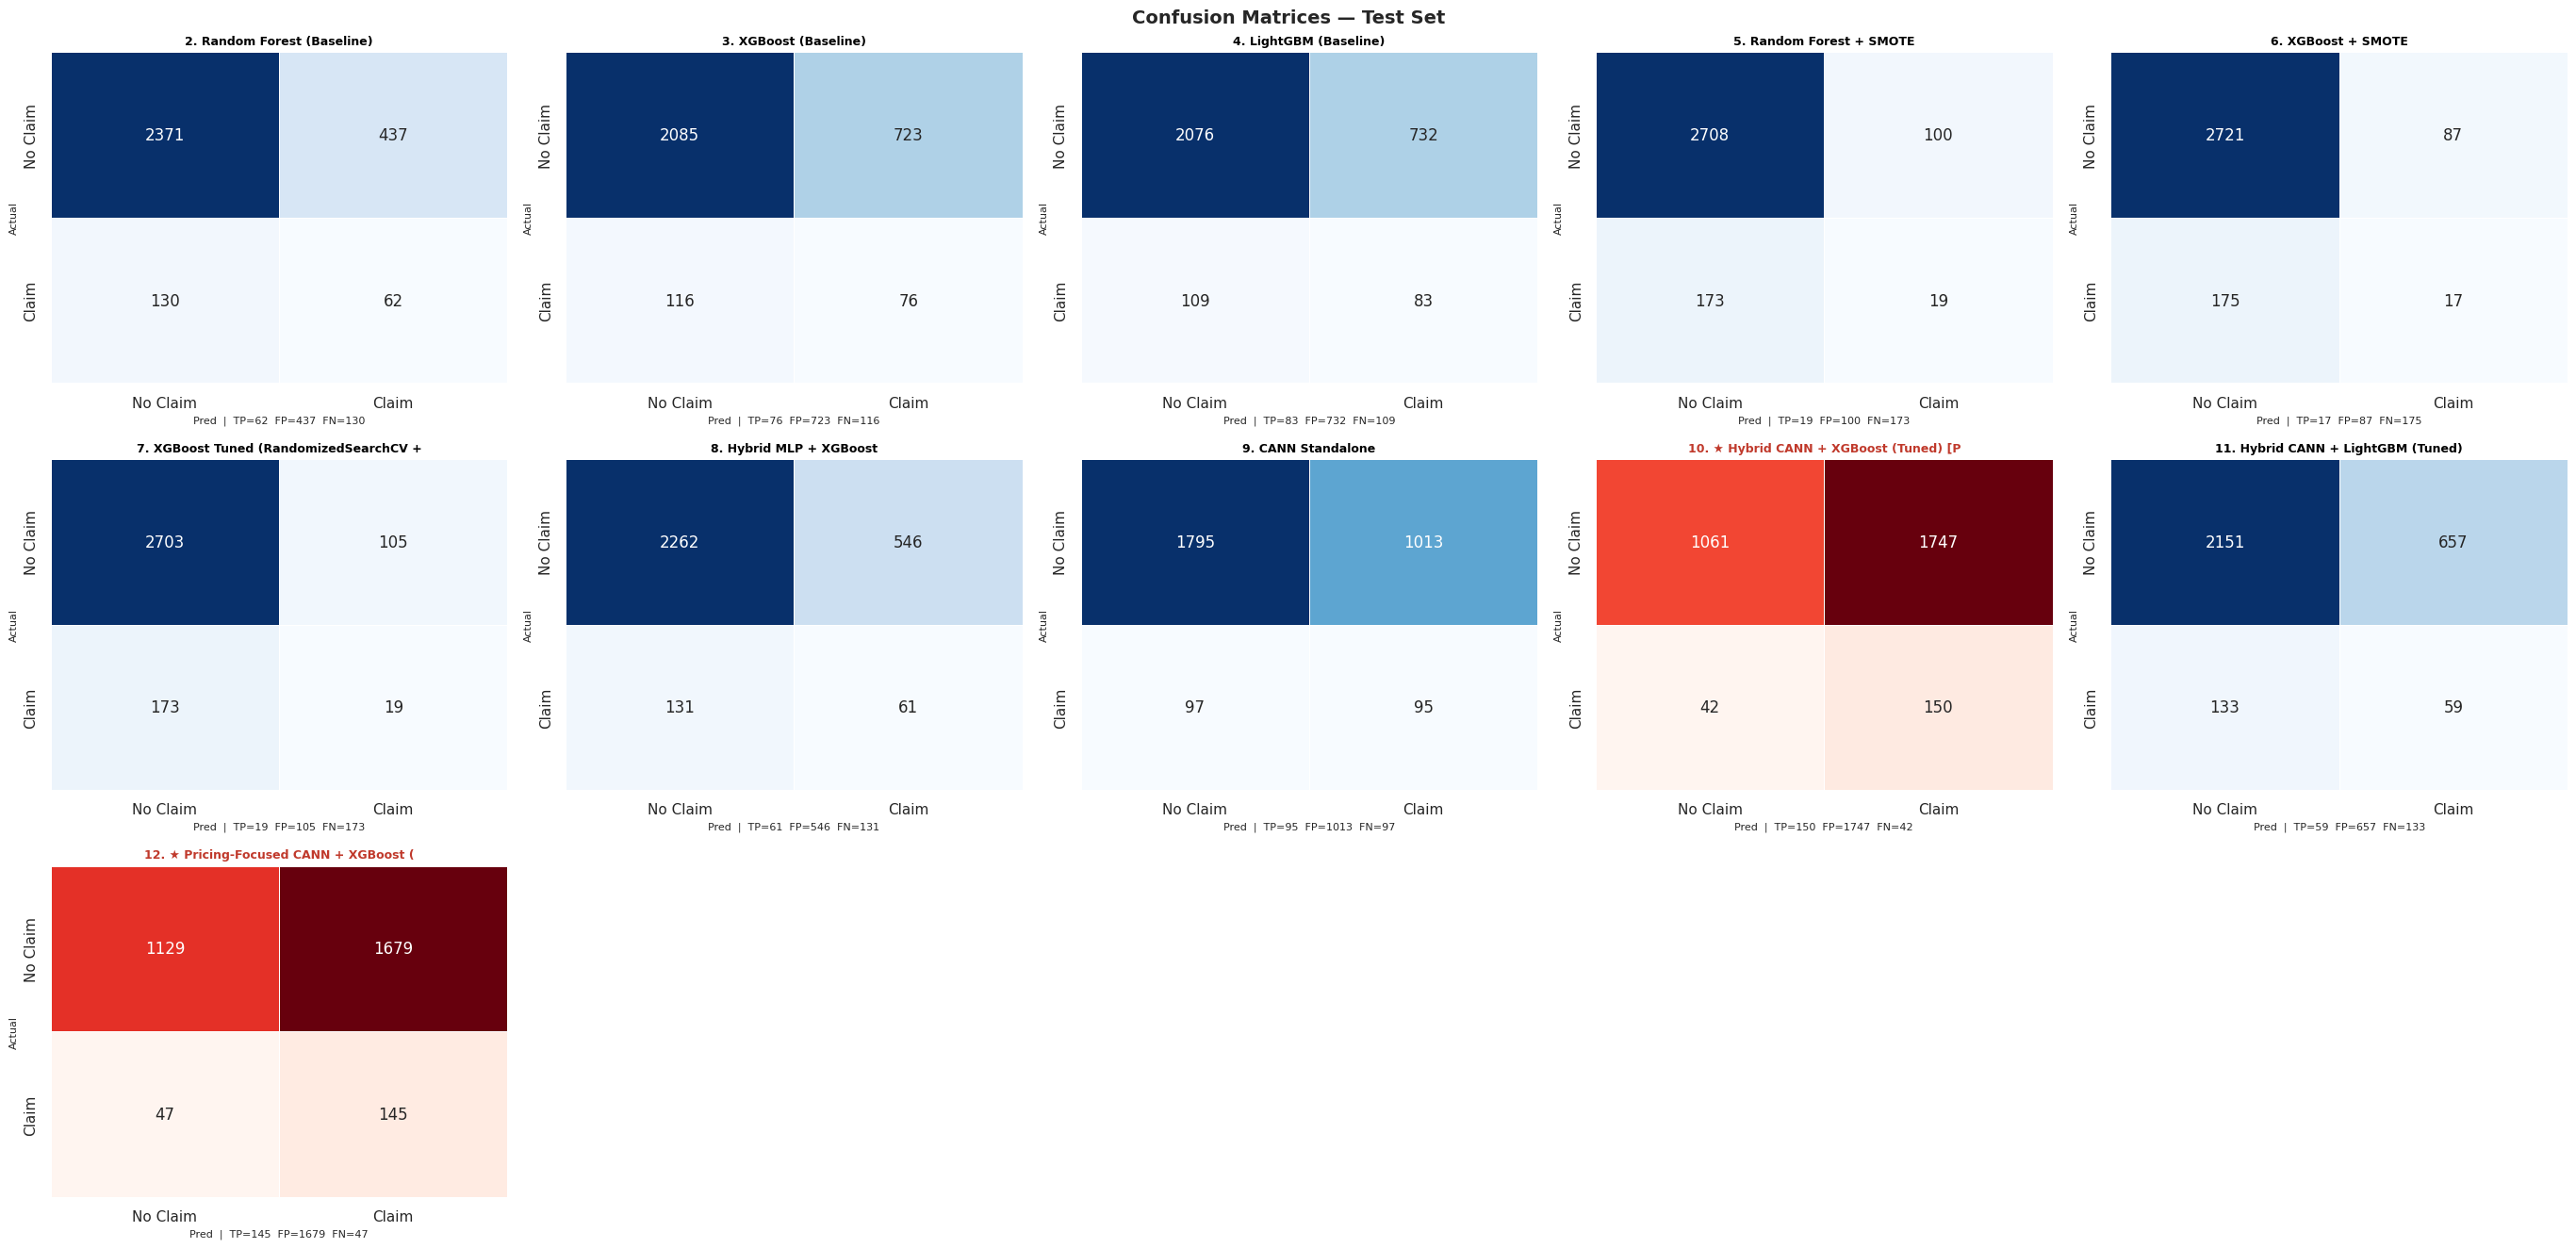

In [20]:
key_models = [k for k in results if k != '1. Logistic Regression']

n_models = len(key_models)
n_cols = 5
n_rows = int(np.ceil(n_models / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5.5, n_rows*4.5))
fig.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
axes = axes.flatten()

for idx, name in enumerate(key_models):
    cm  = confusion_matrix(y_test, results[name]['y_pred'])
    ax  = axes[idx]
    cmap_use = 'Reds' if '★' in name else 'Blues'
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap_use, ax=ax,
                xticklabels=['No Claim','Claim'],
                yticklabels=['No Claim','Claim'],
                linewidths=0.5, cbar=False, annot_kws={'size':12})
    tn,fp,fn,tp = cm.ravel()
    ax.set_title(name[:38], fontsize=9, fontweight='bold',
                 color='#c0392b' if '★' in name else 'black')
    ax.set_xlabel(f'Pred  |  TP={tp}  FP={fp}  FN={fn}', fontsize=8)
    ax.set_ylabel('Actual', fontsize=8)

for j in range(len(key_models), len(axes)): axes[j].axis('off')
plt.tight_layout()
plt.savefig('04_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## SHAP Feature Importance — Proposed CANN + XGBoost

In [21]:
print("Computing SHAP values on the pricing-focused proposed CANN + XGBoost...")
shap_xgb_model = pricing_model.raw_model if 'pricing_model' in globals() else proposed_model.model

deep_dim = cann_train_deep.shape[1]
all_feat_names = feature_names + [f'CANN_Deep_{i}' for i in range(deep_dim)]

# Sample 2000 test rows for SHAP (TreeExplainer is fast on tree models, but plotting
# scales poorly with n_samples).
n_sample = min(2000, len(X_test_cann_hyb))
idx_sample = np.random.choice(len(X_test_cann_hyb), n_sample, replace=False)
X_shap = X_test_cann_hyb[idx_sample]

explainer = shap.TreeExplainer(shap_xgb_model)
shap_values = explainer.shap_values(X_shap)

print(f"SHAP values computed on {n_sample:,} samples.")


Computing SHAP values on the pricing-focused proposed CANN + XGBoost...
SHAP values computed on 2,000 samples.


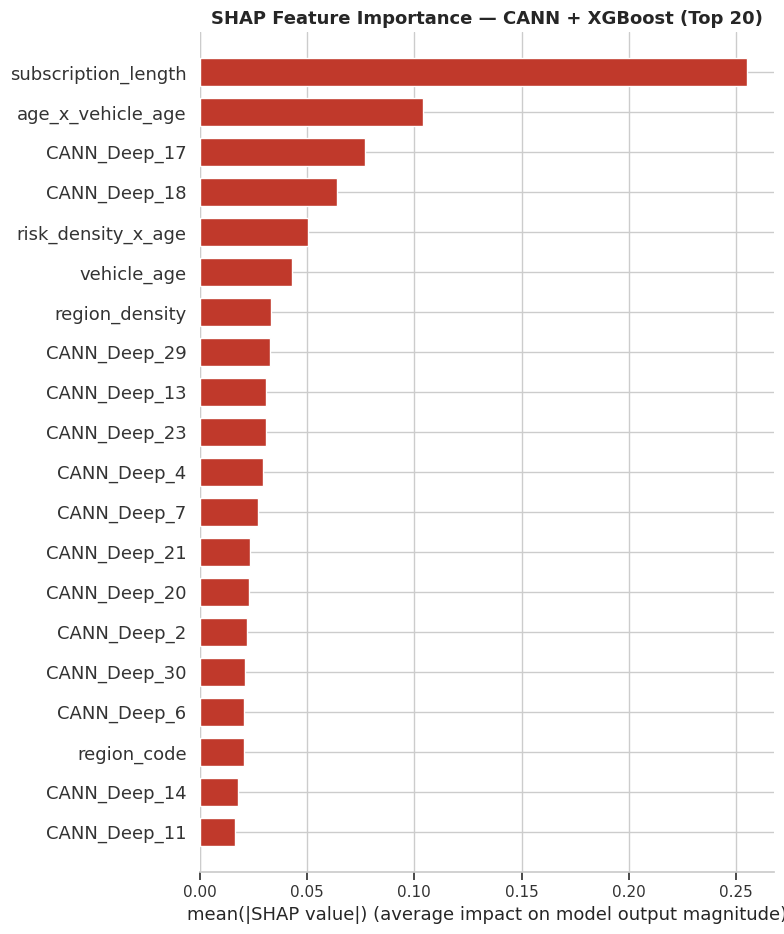

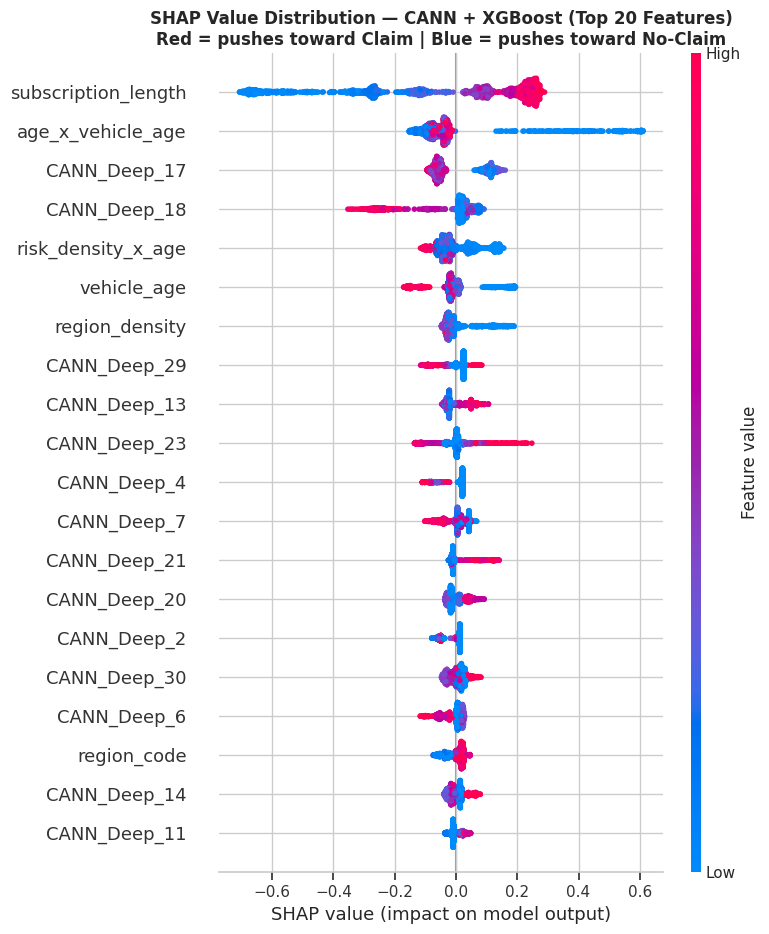


14 of the top 20 features are CANN-learned deep representations.


In [22]:
# Bar plot — Mean |SHAP|
plt.figure(figsize=(11, 9))
shap.summary_plot(shap_values, X_shap, feature_names=all_feat_names,
                  plot_type='bar', show=False, color='#c0392b', max_display=20)
plt.title('SHAP Feature Importance — CANN + XGBoost (Top 20)',
          fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('05_shap_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# Beeswarm plot
plt.figure(figsize=(12, 9))
shap.summary_plot(shap_values, X_shap, feature_names=all_feat_names,
                  plot_type='dot', show=False, max_display=20)
plt.title('SHAP Value Distribution — CANN + XGBoost (Top 20 Features)\n'
          'Red = pushes toward Claim | Blue = pushes toward No-Claim',
          fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('06_shap_beeswarm.png', dpi=150, bbox_inches='tight')
plt.show()

# How many CANN-deep features made it into the top 20?
mean_abs = np.abs(shap_values).mean(axis=0)
top20 = np.argsort(mean_abs)[-20:]
n_cann_top20 = sum(1 for i in top20 if all_feat_names[i].startswith('CANN_Deep'))
print(f"\n{n_cann_top20} of the top 20 features are CANN-learned deep representations.")

## Traditional Feature Importances

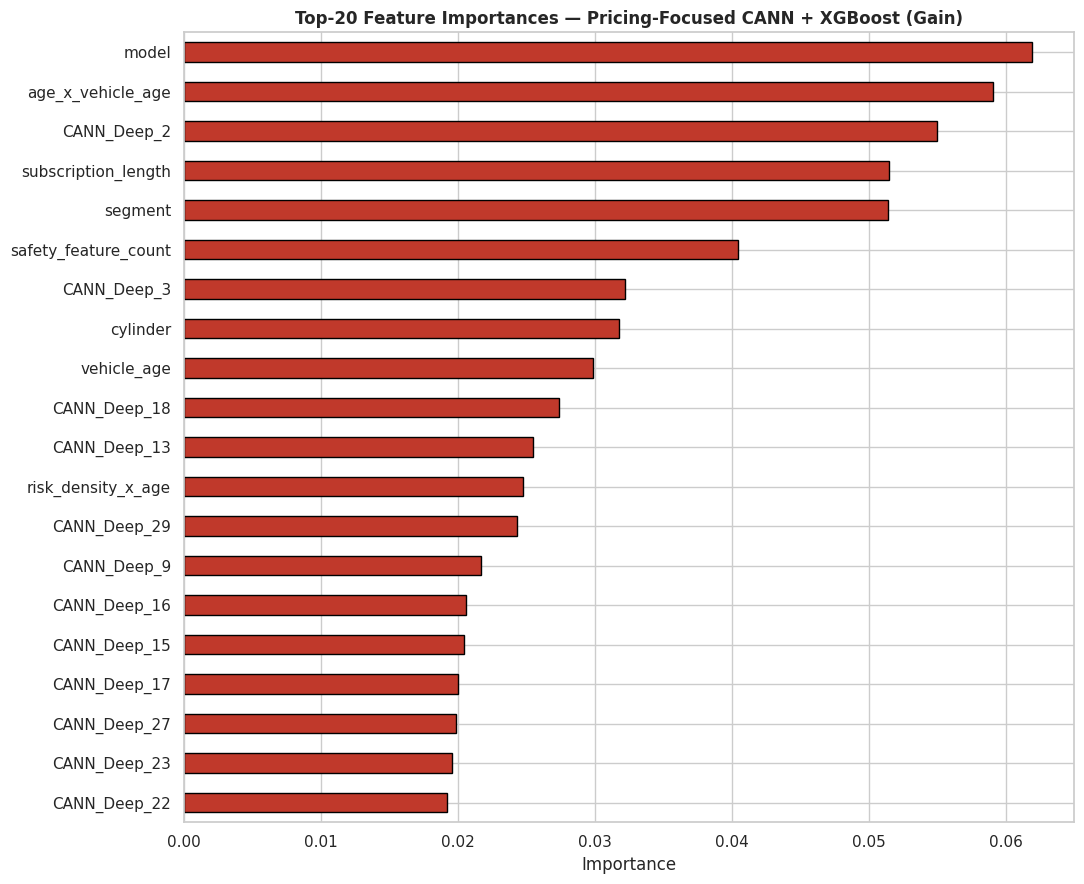

In [23]:
importance_model = pricing_model.raw_model if 'pricing_model' in globals() else proposed_model.model
xgb_imp = pd.Series(importance_model.feature_importances_,
                    index=all_feat_names).sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(11, 9))
xgb_imp.sort_values().plot(kind='barh', ax=ax, color='#c0392b', edgecolor='black')
ax.set_title('Top-20 Feature Importances — Pricing-Focused CANN + XGBoost (Gain)',
             fontweight='bold', fontsize=12)
ax.set_xlabel('Importance')
plt.tight_layout()
plt.savefig('07_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()


## Detailed Report — Proposed Model

In [24]:
key = pricing_key if 'pricing_key' in globals() else '10. ★ Hybrid CANN + XGBoost (Tuned) [PROPOSED]'
print("=" * 65)
print(f"  PROPOSED MODEL: Pricing-Focused Hybrid CANN + XGBoost")
print(f"  Test Set: stratified hold-out ({len(y_test):,} records)")
print("=" * 65)
print(classification_report(y_test, results[key]['y_pred'],
      target_names=['No Claim (0)','Claim (1)'], digits=4))
print(f"AUC-ROC                          : {results[key]['AUC-ROC']:.4f}")
print(f"F1-Score                         : {results[key]['F1-Score']:.4f}")
print(f"Matthews Correlation Coefficient : {results[key]['MCC']:.4f}")
print(f"Average Precision (PR-AUC)       : {results[key]['Avg Precision']:.4f}")
print(f"Log Loss                         : {results[key]['Log Loss']:.4f}")

# Quantify lift over the GLM baseline
glm_ll = results['1. Logistic Regression']['Log Loss']
prop_ll = results[key]['Log Loss']
lift_pct = (glm_ll - prop_ll) / glm_ll * 100
print(f"\nLog-Loss improvement over GLM baseline: {lift_pct:.1f}%  "
      f"({glm_ll:.4f} → {prop_ll:.4f})")


  PROPOSED MODEL: Pricing-Focused Hybrid CANN + XGBoost
  Test Set: stratified hold-out (3,000 records)
              precision    recall  f1-score   support

No Claim (0)     0.9600    0.4021    0.5668      2808
   Claim (1)     0.0795    0.7552    0.1438       192

    accuracy                         0.4247      3000
   macro avg     0.5198    0.5786    0.3553      3000
weighted avg     0.9037    0.4247    0.5397      3000

AUC-ROC                          : 0.5866
F1-Score                         : 0.1438
Matthews Correlation Coefficient : 0.0788
Average Precision (PR-AUC)       : 0.0782
Log Loss                         : 0.2579

Log-Loss improvement over GLM baseline: 62.1%  (0.6797 → 0.2579)


## Radar Chart — Top 5 Models

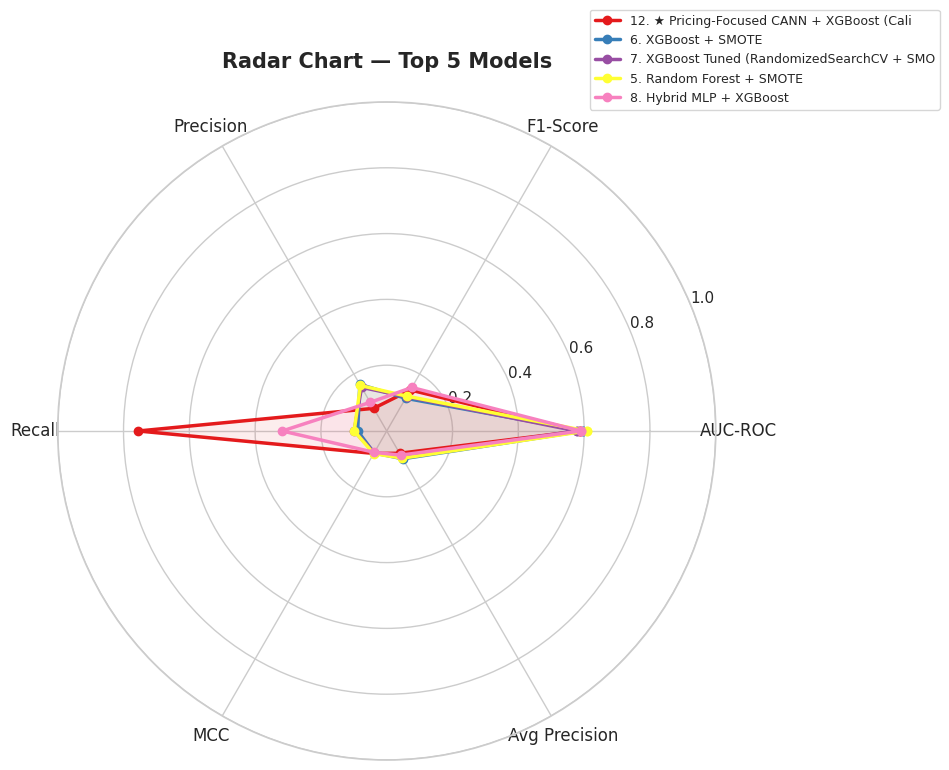

In [25]:
top5_names = lb.head(5).index.tolist()
categories = ['AUC-ROC','F1-Score','Precision','Recall','MCC','Avg Precision']
N_cats = len(categories)
angles = [n/N_cats * 2*np.pi for n in range(N_cats)] + [0]

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'})
colors = plt.cm.Set1(np.linspace(0, 0.8, 5))

for i, name in enumerate(top5_names):
    row = results_df.loc[name]
    vals = [row[c] for c in categories] + [row[categories[0]]]
    ax.plot(angles, vals, 'o-', lw=2.5, label=name[:42], color=colors[i])
    ax.fill(angles, vals, alpha=0.08, color=colors[i])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=12)
ax.set_ylim(0, 1)
ax.set_title('Radar Chart — Top 5 Models', size=15, fontweight='bold', pad=25)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=9)
plt.tight_layout()
plt.savefig('08_radar_top5.png', dpi=150, bbox_inches='tight')
plt.show()

## Premium Pricing Simulation
Once deployed, the proposed CANN+XGBoost scores incoming policy applications and translates predicted claim probabilities into risk-adjusted premiums:

> **Premium = Base × Risk Factor**, where  Risk Factor = 0.5 + 4 · P(claim)

This produces a 0.5×–4.5× multiplier band centered on the portfolio average.

In [26]:
# ── Premium pricing engine: calibrated frequency × severity/relativity ─────
# This replaces the earlier arbitrary premium formula. It uses calibrated claim
# probabilities from the pricing-focused proposed model.

key = pricing_key if 'pricing_key' in globals() else '10. ★ Hybrid CANN + XGBoost (Tuned) [PROPOSED]'
test_probs = results[key]['y_prob']
portfolio_claim_rate = float(y_train_full.mean())

# Commercial assumptions — edit these to match the insurer's tariff rules.
base_portfolio_premium = 1200.0   # average annual premium for portfolio-average risk
expense_loading = 0.25            # acquisition/admin costs
profit_loading = 0.10             # target margin / risk capital loading
min_relativity = 0.50             # fairness/regulatory cap: lowest allowed relativity
max_relativity = 3.50             # fairness/regulatory cap: highest allowed relativity

# Optional claim severity model if a severity target exists.
severity_model = None
if severity_col and sev_train is not None and np.nanmax(sev_train) > 0:
    print(f"Training positive-claim severity model using target: {severity_col}")
    pos_mask = (y_train == 1) & (sev_train > 0)
    severity_model = XGBRegressor(
        n_estimators=300, max_depth=3, learning_rate=0.05,
        subsample=0.85, colsample_bytree=0.85,
        objective='reg:squarederror', n_jobs=-1, random_state=42
    )
    severity_model.fit(X_train_cann_hyb[pos_mask], np.log1p(sev_train[pos_mask]))
    pred_severity = np.expm1(severity_model.predict(X_test_cann_hyb))
    portfolio_avg_severity = float(np.mean(sev_train[pos_mask]))
    expected_loss = test_probs * pred_severity
    portfolio_expected_loss = portfolio_claim_rate * portfolio_avg_severity
    risk_relativity = expected_loss / max(portfolio_expected_loss, 1e-6)
else:
    print("No usable claim severity target found. Pricing uses frequency-based risk relativities.")
    pred_severity = np.repeat(np.nan, len(test_probs))
    expected_loss = np.repeat(np.nan, len(test_probs))
    risk_relativity = test_probs / max(portfolio_claim_rate, 1e-6)

risk_relativity_capped = np.clip(risk_relativity, min_relativity, max_relativity)
technical_premium = base_portfolio_premium * risk_relativity_capped
commercial_premium = technical_premium * (1 + expense_loading + profit_loading)

scored = X_test.copy().reset_index(drop=True)
scored['actual_claim_status'] = y_test.reset_index(drop=True).values
scored['claim_probability_pct'] = (test_probs * 100).round(2)
scored['portfolio_claim_rate_pct'] = round(portfolio_claim_rate * 100, 2)
scored['risk_relativity_raw'] = risk_relativity.round(3)
scored['risk_relativity_capped'] = risk_relativity_capped.round(3)
scored['expected_claim_severity'] = np.round(pred_severity, 2)
scored['expected_loss'] = np.round(expected_loss, 2)
scored['technical_premium_usd'] = technical_premium.round(2)
scored['commercial_premium_usd'] = commercial_premium.round(2)

scored['risk_band'] = pd.cut(
    scored['risk_relativity_capped'],
    bins=[-np.inf, 0.75, 1.25, 2.00, np.inf],
    labels=['Low Risk', 'Moderate Risk', 'Elevated Risk', 'High Risk']
)

print(f"Scored {len(scored):,} policies using calibrated pricing probabilities.")
print(f"Portfolio claim rate used as pricing baseline: {portfolio_claim_rate:.4f}")
print("\nRisk Band distribution:")
print(scored['risk_band'].value_counts().to_string())
print("\nPremium summary by risk band:")
print(scored.groupby('risk_band', observed=True)['commercial_premium_usd']
            .agg(['count','mean','min','max']).round(2).to_string())

# ── Reference: three canonical driver profiles ─────────────────────────────
print("\n" + "=" * 90)
print("  REFERENCE PROFILES — Calibrated Risk-Adjusted Premiums")
print("=" * 90)
median_row = X_test.median()
profiles = {
    'Low-Risk  (experienced, new car)': {
        'customer_age': 45, 'vehicle_age': 1.0, 'subscription_length': 10,
        'airbags': 6, 'ncap_rating': 5},
    'Medium-Risk (average driver)':    {
        'customer_age': 35, 'vehicle_age': 3.0, 'subscription_length': 5,
        'airbags': 2, 'ncap_rating': 3},
    'High-Risk (young, old car)':       {
        'customer_age': 22, 'vehicle_age': 10.0, 'subscription_length': 1,
        'airbags': 0, 'ncap_rating': 0},
}
print(f"{'Profile':<38s} {'P(claim)':>10s} {'Relativity':>12s} {'Risk':>14s} {'Premium (USD)':>16s}")
print("-" * 90)
cann.eval()
for label, overrides in profiles.items():
    row = median_row.copy()
    for k, v in overrides.items():
        if k in row.index:
            row[k] = v
    Xs = scaler.transform(row.values.reshape(1, -1))
    with torch.no_grad():
        deep = cann.extract_features(torch.FloatTensor(Xs).to(device)).cpu().numpy()
    Xh = np.hstack((row.values.reshape(1, -1), deep))
    p = float(pricing_model.predict_proba(Xh)[:, 1][0]) if 'pricing_model' in globals() else float(proposed_model.predict_proba(Xh)[:, 1][0])
    rel = float(np.clip(p / max(portfolio_claim_rate, 1e-6), min_relativity, max_relativity))
    prem = base_portfolio_premium * rel * (1 + expense_loading + profit_loading)
    band = pd.cut([rel], bins=[-np.inf,0.75,1.25,2.00,np.inf],
                  labels=['Low Risk','Moderate Risk','Elevated Risk','High Risk'])[0]
    print(f"{label:<38s} {p:>9.2%} {rel:>12.3f} {str(band):>14s} {prem:>16,.2f}")


No usable claim severity target found. Pricing uses frequency-based risk relativities.
Scored 3,000 policies using calibrated pricing probabilities.
Portfolio claim rate used as pricing baseline: 0.0640

Risk Band distribution:
risk_band
Elevated Risk    1616
Low Risk         1144
High Risk         167
Moderate Risk      73

Premium summary by risk band:
               count     mean      min      max
risk_band                                      
Low Risk        1144   810.00   810.00   810.00
Moderate Risk     73  1493.82  1406.25  1914.47
Elevated Risk   1616  2105.77  2104.99  2735.60
High Risk        167  3727.66  3543.75  3927.80

  REFERENCE PROFILES — Calibrated Risk-Adjusted Premiums
Profile                                  P(claim)   Relativity           Risk    Premium (USD)
------------------------------------------------------------------------------------------
Low-Risk  (experienced, new car)           8.32%        1.299  Elevated Risk         2,104.99
Medium-Risk (aver

## Save Artefacts

In [27]:
# Save model artefacts
model_to_save = pricing_model if 'pricing_model' in globals() else proposed_model
raw_xgb_to_save = model_to_save.raw_model if hasattr(model_to_save, 'raw_model') else model_to_save.model

torch.save(cann.state_dict(), 'cann_model.pt')
raw_xgb_to_save.save_model('xgb_pricing_proposed.json')
joblib.dump(scaler, 'scaler.joblib')
if 'pricing_calibrated_model' in globals():
    joblib.dump(pricing_calibrated_model, 'calibrated_pricing_model.joblib')
if 'severity_model' in globals() and severity_model is not None:
    joblib.dump(severity_model, 'severity_model.joblib')

# Save results
results_df.to_csv('model_comparison_results.csv')
scored.to_csv('insurance_premium_predictions.csv', index=False)

champion = lb.index[0]
metrics_summary = {
    'pricing_champion': champion,
    'proposed_model_key': pricing_key if 'pricing_key' in globals() else '10. ★ Hybrid CANN + XGBoost (Tuned) [PROPOSED]',
    'ranking_basis': 'Log Loss first, then Average Precision and MCC',
    'AUC_ROC': float(lb.loc[champion,'AUC-ROC']),
    'F1': float(lb.loc[champion,'F1-Score']),
    'MCC': float(lb.loc[champion,'MCC']),
    'Avg_Precision': float(lb.loc[champion,'Avg Precision']),
    'Log_Loss': float(lb.loc[champion,'Log Loss']),
    'best_xgb_params_raw_space': xgb_best_params,
    'best_xgb_params_hybrid_space': xgb_hyb_best,
    'pricing_best_params': best_pricing['best_params'] if 'best_pricing' in globals() else None,
    'pricing_scale_pos_weight': float(best_pricing['scale_pos_weight']) if 'best_pricing' in globals() else None,
    'pricing_calibration_method': best_pricing['calibration_method'] if 'best_pricing' in globals() else None,
    'best_reporting_threshold_mcc': float(best_mcc_threshold) if 'best_mcc_threshold' in globals() else float(best_thresh),
    'base_portfolio_premium': float(base_portfolio_premium),
    'expense_loading': float(expense_loading),
    'profit_loading': float(profit_loading),
    'min_relativity': float(min_relativity),
    'max_relativity': float(max_relativity),
    'severity_target_col': severity_col,
    'cann_architecture': '128-64-32 + GLM skip connection (warm-started from LR)',
    'deep_feature_dim': int(deep_dim),
    'training_size': int(len(X_train)),
    'test_size': int(len(X_test)),
}
with open('best_model_metrics.json', 'w') as f:
    json.dump(metrics_summary, f, indent=2)

print("Artefacts saved:")
for fn in ['cann_model.pt', 'xgb_pricing_proposed.json', 'scaler.joblib',
           'calibrated_pricing_model.joblib', 'severity_model.joblib',
           'model_comparison_results.csv', 'insurance_premium_predictions.csv',
           'best_model_metrics.json']:
    try:
        import os
        if os.path.exists(fn): print(f"  • {fn}")
    except Exception:
        pass

# Optional: download in Colab
try:
    from google.colab import files
    for fn in ['model_comparison_results.csv', 'insurance_premium_predictions.csv',
               'best_model_metrics.json']:
        files.download(fn)
except Exception as e:
    print(f"\n(Note: not running in Colab — {type(e).__name__})")


Artefacts saved:
  • cann_model.pt
  • xgb_pricing_proposed.json
  • scaler.joblib
  • calibrated_pricing_model.joblib
  • model_comparison_results.csv
  • insurance_premium_predictions.csv
  • best_model_metrics.json


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>